# Step-by-step summary of my reasoning

I started from the original **PD-LMC** structure in the paper. The algorithm assumes that we want to sample from a target distribution

$$
\pi(x) \propto e^{-f(x)}
$$

under constraints, by introducing a dual variable $\lambda$ and running a Langevin step on a modified energy

$$
U(x,\lambda) = f(x) + \lambda g(x).
$$

The primal update is then

$$
x_{k+1}=x_k - \eta_x \nabla_x U(x_k,\lambda_k) + \sqrt{2\eta_x}\,\xi_k,\qquad\xi_k \sim \mathcal N(0,I),
$$

and the dual variable is updated by

$$
\lambda_{k+1}=\big[\lambda_k + \eta_\lambda g(x_{k+1})\big]_+.
$$

My first question was therefore: **what plays the role of $-\nabla f$ in a diffusion model?**

In the **DSM / score-based** setting, we do not have direct access to an explicit energy $f$, but we learn a **score function**

$$s_\theta(x_t,t) \approx \nabla_{x_t} \log p_t(x_t),$$

where $p_t$ is the distribution of noisy data at time $t$. But in standard Langevin dynamics, we know that

$$
\nabla \log \pi(x) = -\nabla f(x).
$$

So I concluded that, in the DSM setting, the model score plays exactly the role of the drift term used in Langevin dynamics. In other words, the unconstrained primal step can be written as

$$
x_{k+1}=x_k + \eta\, s_\theta(x_k,t_k) + \sqrt{2\eta}\,\xi_k.
$$

From there, the natural PD-LMC adaptation is to add a dual-weighted constraint term to this drift. This leads to a constrained dynamics of the form

$$
x_{k+1}=x_k+\eta\Big(s_\theta(x_k,t_k) - \lambda_k \nabla g(x_k)\Big)+\sqrt{2\eta}\,\xi_k,
$$

together with the dual update

$$
\lambda_{k+1}=\big[\lambda_k + \eta_\lambda g(x_{k+1})\big]_+.
$$

My first conclusion was therefore that, in a DSM model, **we can almost reuse the exact same PD-LMC structure**, the main difference being that the gradient of the energy is replaced by the **learned score**.

Next, I asked myself whether the constraint should be applied directly to $x_t$, i.e. the noisy state, or rather to a denoised quantity closer to the final sample. This led me to introduce an estimate of the clean sample, denoted $\hat x_0$, because in practice semantic constraints such as “being a 4”, “having a given brightness”, or “matching a known mask for inpainting” are much more meaningful on the final clean image than on a highly noisy intermediate state.

To justify this mathematically, I used the fact that in DSM one has a Tweedie-type relation:

$$
\mathbb{E}[x_0 \mid x_t] = \frac{x_t + (1 - \bar{\alpha}_t) \nabla_{x_t} \log p_t(x_t)}{\sqrt{\bar{\alpha}_t}}
$$

Since the learned score approximates this gradient, this yields the natural estimate

$$
\hat{x}_0(x_t, t) = \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \epsilon_\theta(x_t, t)}{\sqrt{\bar{\alpha}_t}}
$$

So I concluded that the constraint should ideally be imposed on $\hat x_0$, rather than directly on $x_t$.

At that point, the constraint is no longer simply $g(x_t)$, but instead

$$
g(\hat x_0(x_t,t)).
$$

The primal step therefore becomes

$$
x_{k+1}=x_k+\eta\Big(s_\theta(x_k,t_k)-\lambda_k \nabla_{x_k} g(\hat x_0(x_k,t_k))\Big)+\sqrt{2\eta}\,\xi_k.
$$

At this stage, I realized that there is an important technical point: the gradient of the constraint must be taken **with respect to $x_t$**, while $g$ itself is defined on $\hat x_0$. Therefore, the chain rule must be used
In practice, the idea is simply to construct $\hat x_0(x_t,t)$, evaluate the constraint on it, and then obtain

$$
\nabla_{x_t} g(\hat x_0(x_t,t))
$$

by automatic differentiation. So this adaptation fits naturally within a deep learning framework.





---

**So basically At each noise level $t$, I interpret the score model as defining a reference distribution $p_t$, with score**

$$
s_\theta(x,t)\approx \nabla_x \log p_t(x).
$$

Then the constrained version naturally corresponds to the KL problem

$$
\min_{\mu_t}\; \mathrm{KL}(\mu_t \,\|\, p_t)\qquad\text{s.t.}\qquad\mathbb E_{\mu_t}[g_t(X)] \le 0.
$$

The solution of this constrained problem is a tilted distribution of the form

$$
\mu_t^\lambda(x)\propto p_t(x)\exp(-\lambda g_t(x)),
$$

whose score is

$$
\nabla_x \log \mu_t^\lambda(x)=\nabla_x \log p_t(x)-\lambda \nabla_x g_t(x).
$$

So, at least formally, adapting PD-LMC to DSM amounts to replacing the original score $\nabla_x \log p_t(x)$ by a constrained score of the form

$$
\nabla_x \log p_t(x)-\lambda \nabla_x g_t(x).
$$















Once this structure was established, I considered the kinds of constraints that could be imposed without retraining the generative model.

For **class-conditional generation**, I can use a frozen classifier $p_\phi(y \mid x)$ and define

$$
g(x) = \tau - p_\phi(y=c \mid x),
$$

so that $\lambda$ increases whenever the probability of the desired class is too small.

For **inpainting**, I can impose consistency with the observed pixels through a constraint such as

$$
g(x) = \|M \odot (x-y)\|^2 - \varepsilon.
$$

For **brightness control**, I can use

$$
g(x) = |\mathrm{mean}(x) - b^\star| - \varepsilon.
$$


# Numerical Application

## Pratical choice for the pratical bonus : Using DDPM 

At first, my idea was to adapt PD-LMC directly to a DSM model, because this is the cleanest theoretical setting. In DSM, sampling is already written in a Langevin-like form, so the connection with PD-LMC is very natural. However, for a first practical proof of concept on MNIST, I decided to work with a pretrained DDPM instead.

The reason is mostly practical: a pretrained DDPM on MNIST is much easier for me to load, test, and modify quickly, while still keeping the same primal-dual intuition as PD-LMC. So, even if DSM is conceptually cleaner, I think DDPM is a better choice here for a simple and convincing experiment.

In a DDPM, at each reverse step $t$, the model predicts either the noise $\varepsilon_\theta(x_t,t)$ or, equivalently, an estimate of the clean image $\hat x_0(x_t,t)$. From this, it computes a reverse mean $\mu_\theta(x_t,t)$ and generates the next state through

$$
x_{t-1} = \mu_\theta(x_t,t) + \sigma_t z,\qquad z \sim \mathcal N(0,I).
$$

My idea is to keep exactly the same logic as PD-LMC, but to inject it into this reverse DDPM step. In the same idea nstead of constraining the noisy state $x_t$, I impose the constraint on the estimated clean image $\hat x_0(x_t,t)$, because this is where the semantic meaning of the sample is the clearest. For example, if I want to generate only 4s, the classifier should obviously be applied to the reconstructed clean digit rather than to a noisy intermediate state.

If I denote the constraint by $g(\hat x_0)$, then the modified reverse step becomes

$$
x_{t-1}=\mu_\theta(x_t,t)-\gamma_t \lambda_t \nabla_{x_t} g(\hat x_0(x_t,t))+\sigma_t z,
$$

where $\gamma_t$ is a guidance step size. In my view, this is the DDPM analogue of the primal step in PD-LMC: the DDPM model keeps the trajectory on the manifold of realistic digits, while the dual correction term pushes the sample toward satisfying the constraint.

Then, after each reverse step, I update the dual variable exactly in the spirit of PD-LMC:

$$
\lambda_{t-1}=\big[\lambda_t + \eta_\lambda\, g(\hat x_0(x_t,t))\big]_+
$$

So the reasoning I follow is the following:
1. use the pretrained DDPM as the base generative dynamics;
2. reconstruct $\hat x_0(x_t,t)$ at each reverse step;
3. evaluate the constraint on this estimated clean image;
4. add a dual-weighted correction to the reverse mean;
5. update $\lambda$ after each step by projected ascent.

## Controllable Generation MNIST

In this experiment, I study a **training-free primal-dual guidance** strategy on a pretrained unconditional **DDPM** trained on MNIST. Starting from the standard reverse diffusion process, I reconstruct an estimate of the clean image at each step and evaluate a semantic constraint on it using a frozen classifier. The objective is to steer the generation toward a target digit  while keeping the sample on the data manifold. The guidance is controlled by a dual variable $\lambda$, updated online during sampling, in the spirit of **PD-LMC**.

Import 

In [12]:
from PD_LMC_diffusion.Controllable_generation_MNIST.controllable_generation_mnist import (
    get_device,
    set_seed,
    get_mnist_dataloaders,
    SimpleCNN,
    train_classifier,
    plot_classifier_history,
    load_classifier,
    load_ddpm_pipeline,
    generate_digit,
    compare_guided_vs_baseline,
    plot_generation_results,
)

Data

In [13]:
device = get_device()
print("device:", device)

train_loader, test_loader = get_mnist_dataloaders(
    data_dir="./data",
    batch_size=256,
    num_workers=2,
)

device: mps


Train classifier 

Epoch 1/3 | train_loss=0.2774 train_acc=0.9210 | test_loss=0.0786 test_acc=0.9751
Epoch 2/3 | train_loss=0.0651 train_acc=0.9804 | test_loss=0.0511 test_acc=0.9829
Epoch 3/3 | train_loss=0.0438 train_acc=0.9865 | test_loss=0.0414 test_acc=0.9868


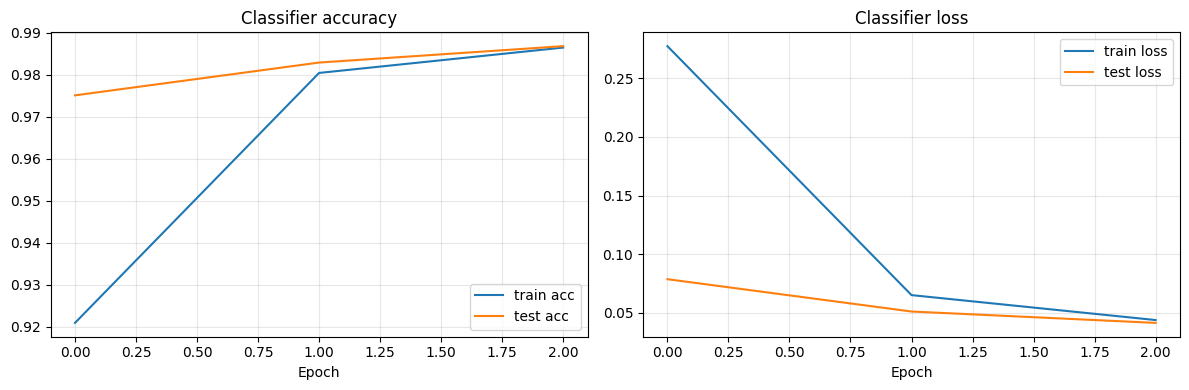

In [3]:
set_seed(0)

classifier = SimpleCNN().to(device)

history = train_classifier(
    model=classifier,
    train_loader=train_loader,
    test_loader=test_loader,
    device=device,
    epochs=3,
    lr=2e-3,
    save_path="./PD_LMC_diffusion/Controllable_generation_MNIST/mnist_classifier.pt",
)

plot_classifier_history(history)

Load Classifier and diffusion model

In [14]:
classifier = load_classifier(
    checkpoint_path="./PD_LMC_diffusion/Controllable_generation_MNIST/mnist_classifier.pt",
    device=device,
)


In [15]:
pipe, unet, scheduler = load_ddpm_pipeline(
    model_id="1aurent/ddpm-mnist",
    device=device,
)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

 Experiences

In [19]:
baseline, guided = compare_guided_vs_baseline(
    unet=unet,
    scheduler=scheduler,
    classifier=classifier,
    device=device,
    target_digit=4,      # change ici si tu veux 7, 9, etc.
    lr_lambda=0.01,
    lr_x=2.0,
    seed=7,             # même seed pour baseline ET guided
    num_steps=1000,
    target_confidence=0.9,
    grad_clip=0.05,
)

baseline2, guided2 = compare_guided_vs_baseline(
    unet=unet,
    scheduler=scheduler,
    classifier=classifier,
    device=device,
    target_digit=8,      # change ici si tu veux 7, 9, etc.
    lr_lambda=0.01,
    lr_x=2.0,
    seed=45,             # même seed pour baseline ET guided
    num_steps=1000,
    target_confidence=0.9,
    grad_clip=0.05,
)



Generation target=4 guided=False:   0%|          | 0/1000 [00:00<?, ?it/s]

Generation target=4 guided=True:   0%|          | 0/1000 [00:00<?, ?it/s]

Generation target=8 guided=False:   0%|          | 0/1000 [00:00<?, ?it/s]

Generation target=8 guided=True:   0%|          | 0/1000 [00:00<?, ?it/s]

Plot

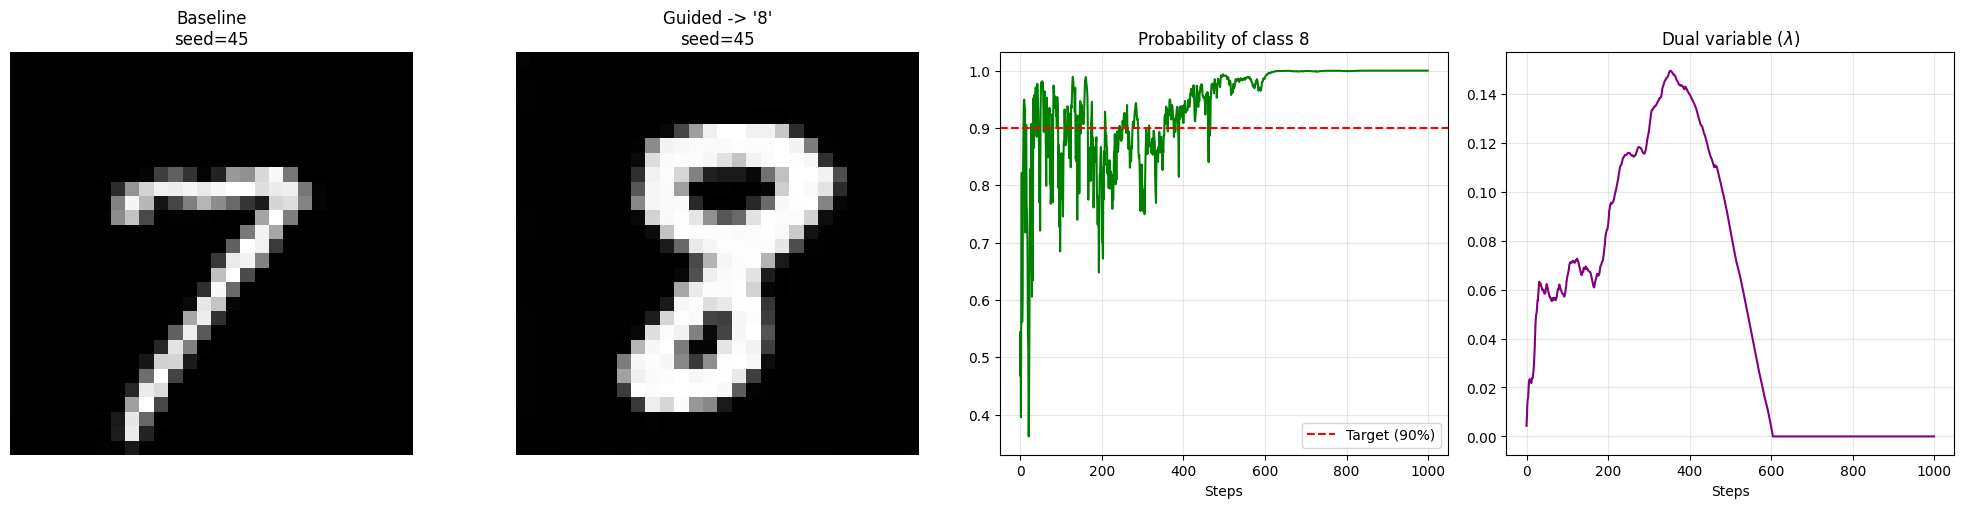

In [20]:
plot_generation_results(baseline2, guided2)

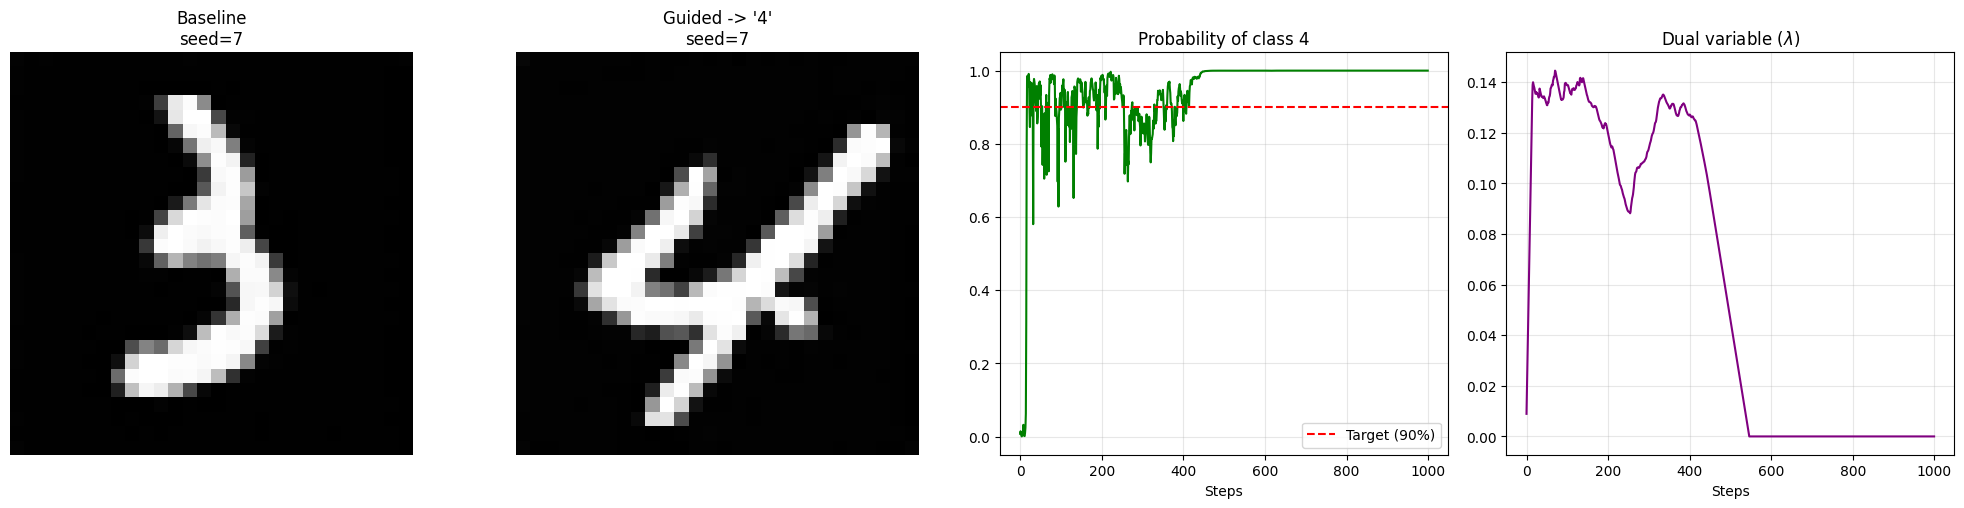

In [21]:
plot_generation_results(baseline, guided)

Overall, this works quite well. Starting from the exact same initial noise, the unguided DDPM produces a sample that does not really look like the target digit, while the guided version is clearly pushed toward a much more convincing **4**. So at least qualitatively, the primal-dual guidance seems to do what it is supposed to do.

The probability curve also supports this. The confidence for class **4** increases during sampling and eventually goes well above the 90% target. At the same time, the dual variable $\lambda$ becomes active when the constraint is not yet satisfied, then progressively goes back down once the classifier is confident enough. This is reassuring, because it means the guidance is not just pushing all the time: it mainly acts when needed.

That said, getting to this result still required a few trials to find reasonable hyperparameters. In particular, I had to clip the gradients to stabilize the guidance. Without gradient clipping, the updates were much more erratic and it was harder to obtain clean digits consistently.

## Controllable brightness 


In this experiment, I apply the same primal-dual idea to a pretrained unconditional **DDPM** on **CelebA-HQ 256**. The goal is to modify the generated image so that it satisfies two constraints at the same time: a target **brightness level** and a **structure preservation** constraint with respect to a reference baseline image generated from the same initial noise. This results in a simple multi-objective training-free guidance method, where one dual variable is associated with brightness and another with structure, allowing the sampler to balance both objectives during reverse diffusion. 

Import

In [7]:
from PD_LMC_diffusion.Controllable_generation_CelebA.controllable_generation_celebahq import (
    get_device,
    set_seed,
    load_celebahq_ddpm,
    generate_baseline_face,
    generate_guided_face,
    compare_baseline_vs_guided_faces,
    plot_face_guidance_results,
)

Data

In [8]:
device = get_device()
print("device:", device)

pipe, unet, scheduler = load_celebahq_ddpm(
    model_id="google/ddpm-celebahq-256",
    device=device,
)

device: mps


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /Users/samuelmarthely/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/samuelmarthely/.cache/huggingface/hub/models--google--ddpm-celebahq-256/snapshots/cd5c944777ea2668051904ead6cc120739b86c4d.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Experiences

In [9]:
baseline_face, guided_face = compare_baseline_vs_guided_faces(
    unet=unet,
    scheduler=scheduler,
    device=device,
    seed=15,
    num_steps=500,
    target_brightness=0.80,
    structure_eps=0.005,
    lr_x=10.0,
    lr_lambda_light=20.0,
    lr_lambda_struct=10.0,
    grad_clip=0.01,
)

Baseline generation (seed=15):   0%|          | 0/500 [00:00<?, ?it/s]

Guided generation (seed=15):   0%|          | 0/500 [00:00<?, ?it/s]

Plot

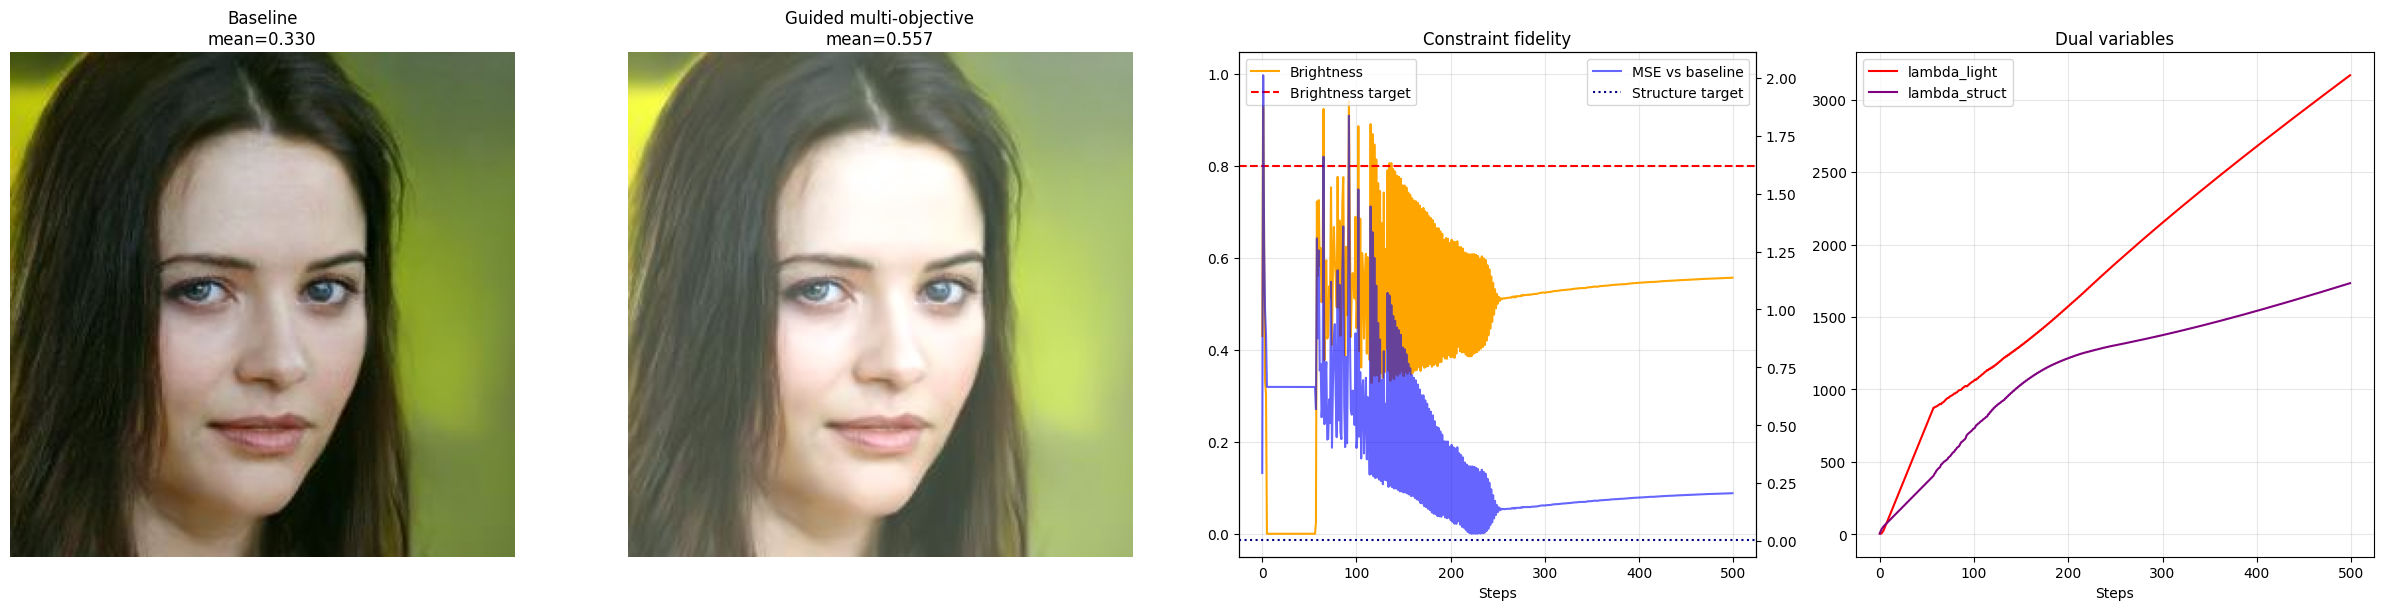

In [10]:
plot_face_guidance_results(
    baseline=baseline_face,
    guided=guided_face,
    target_brightness=0.80,
    structure_eps=0.005,
)



This experiment was much harder to stabilize than the MNIST one. At first, I often observed a kind of **drift / mode collapse**: the guidance was able to make the image brighter, but sometimes by moving toward a quite different face instead of simply modifying the original sample.

This is why I added a second **structure constraint**, to keep the guided image attached to the baseline generated from the same initial noise. In that sense, the constrained-learning viewpoint was really useful here: I ended up using two constraints at once, one for **brightness** and one for **data attachment**.

The result is only partially successful, but still interesting. The guided image is clearly brighter than the baseline, with the mean intensity increasing from about **0.33** to **0.557**, and the face remains globally similar to the original one. So the extra structure constraint does help. However, the constraints are still not fully satisfied: the brightness does not reach the target **0.80**, and the structure metric also stays above its desired threshold. This is also reflected by the two dual variables, which keep increasing, showing that both constraints remain active throughout most of the reverse process.

So overall, this works to some extent, but it was much more of an optimization nightmare than I expected. I think the result could probably be improved with better hyperparameter tuning, but I did not have enough time to explore that properly.

# Limitation

**Limitation.** One subtle point is that this formulation is only **local in time**. At each noise level $t$, I define a constrained problem of the form
$$
\min_{\mu_t}\; \mathrm{KL}(\mu_t \,\|\, p_t)\qquad\text{s.t.}\qquad\mathbb E_{\mu_t}[g_t(X)] \le 0,
$$
where $p_t$ is the marginal noisy-data distribution at time $t$. This gives a clean instantaneous correction of the score, but it also means that I am effectively solving a **different constrained problem at each time step**. So, while the resulting guided dynamics is formally natural, it is not yet a fully global constrained reverse process defined at the path level. In other words, the construction is theoretically well motivated, but it remains **time-local rather than fully pathwise**.